In [245]:
#Diffraction Experiment Notebook for Analysis - Physics Lab III Experiment 6
import matplotlib.pyplot as plt
import numpy as np

#plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

def rsq(y, y_fit):
    y = np.asarray(y)
    y_fit = np.asarray(y_fit)

    ss_res = np.sum((y - y_fit)**2)          
    ss_tot = np.sum((y - np.mean(y))**2)     
    val = 1 - ss_res / ss_tot
    return val


# Part I - Particle Size

Mean :  3.5736986301369864
Standard Deviation : 1.5733830637643809


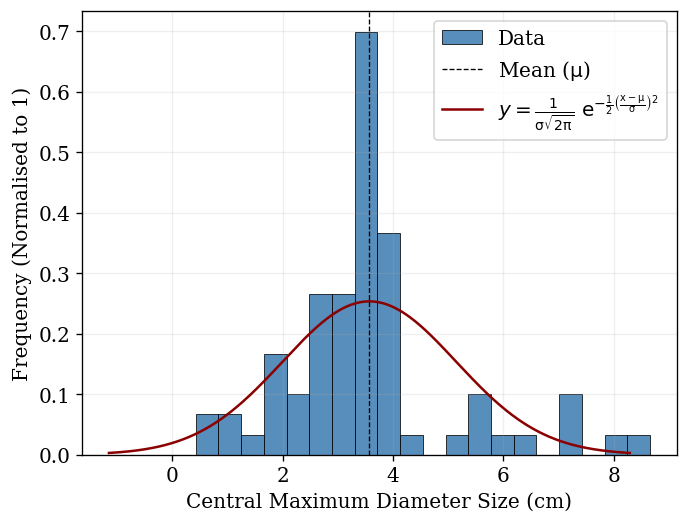

In [246]:
#Histogram
rawdata = np.array([8.66,7.11,4.015,7.035,6.465,4.12,7.42,8.095,5.705,5.575,5,6.065,4.39,5.405,2.585,3.005,2.055,3.925,3.765,3.935,2.965,3.54,2.89,3.785,1.51,3.885,2.94,3.685,1.955,3.505,3.65,2.895,3.415,3.6,3.97,3.58,3.065,0.55,0.91,3.425,3.335,3.66,2.93,3.6,3.285,3.59,0.425,3.575,1.715,3.565,3.05,2.525,3.915,3.75,3.485,3.645,3.33,1.03,3.41,1.87,3.47,2.34,2.46,1.795,2.225,2.85,3.495,2.515,2.59,3.795,2.765,3.6,3.24])


def gethist(raws):
    #Function to return gaussian of some x data
    mean = np.mean(raws)
    sigma = np.std(raws)
    xarr = np.linspace(mean - 3*sigma, mean + 3*sigma, 1000)
    const = 1 / (sigma * (np.sqrt(2*np.pi)))
    pows = - ((xarr - mean)**2 / (2*sigma**2))
    expterm = np.exp(pows)
    yarr = const*expterm
    return xarr, yarr, mean, sigma

x,y,mean, sigma = gethist(rawdata)


plt.hist(rawdata, bins=20, label="Data", color='steelblue', edgecolor='black',linewidth=0.5, alpha=0.9, density=True)
plt.axvline(3.5736986301369864, c="k", lw=0.8, ls="--", label=r"Mean ($\mathrm{\mu}$)")
plt.plot(x,y, c='darkred', label=r'$y = \mathrm{\frac{1}{\sigma\sqrt{2\pi}} \ e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}}$')
plt.grid(alpha = 0.2)
plt.xlabel("Central Maximum Diameter Size (cm)")
plt.ylabel("Frequency (Normalised to 1)")
plt.legend()

print("Mean : ", mean)
print("Standard Deviation :", sigma)
plt.savefig("histogram_particle.jpg")

## $\theta = \sin \theta = \tan \theta = \frac{\mu}{L}$
## $\sin \theta = 1.22 \frac{\lambda}{d}$
## $d = \frac{1.22 \times \lambda \times L }{\mu}$

In [247]:
d = (1.22 * (550*10**(-9)) * (162.5/100)) / (3.57/100)
print(d)
print(f"Diameter of particle: {d * 10**6:.2f} \u03bcm")

3.054271708683474e-05
Diameter of particle: 30.54 μm


# Part II - Surface Tension of Water

In [248]:
#functions and arrays
d_array1 = np.array([0.54,0.63,0.67,0.7,0.74,0.8,0.84,0.87,0.89,0.93,0.96])/100 #cm / 100 --> m SET 1
d_array2 = np.array([0.6,0.65,0.66,0.72,0.75,0.8,0.82,0.84,0.88,0.93,0.95])/100 #SET 2
d_array3 = np.array([0.6,0.64,0.65,0.71,0.76,0.82,0.84,0.91,0.89,0.95, 0.98])/100 #SET 3
w_array = np.array([110,120,130,140,150,160,170,180,190,200,210]) #Hz same for all

h = 48/100
l = 252/100
wav = 650 * 10**(-9) #m

def getk(darr):
    klist = []
    theta = np.arctan(h/l)
    for i in darr:
        d=i
        gamma = np.arctan((h+(d/2))/l) - theta 
        k = (2*np.pi*(np.sin(theta))*(np.sin(gamma))) / wav
        klist.append(k)
    return klist

def plotlogs(darr):
    karr = getk(darr)
    logk = np.log(karr)
    plt.scatter(logk, logw, s=20, c='firebrick', label='Data')
    a,b = np.polyfit(logk, logw, deg=1)
    y_fit = a*logk + b
    rsqval = rsq(logw, y_fit)
    plt.plot(logk, y_fit, ls="--", c='k', label=fr"Best fit: $\ln(\omega) = {a:.2f}\ln(k) - {abs(b):.2f}$")
    plt.xlabel(r"$\mathrm{log_e(k)}$")
    plt.ylabel(r"$\mathrm{log_e(\omega)}$")
    plt.plot([], [], ' ', label=fr"$R^2 = {rsqval:.4f}$")
    plt.legend()
    plt.grid(alpha=0.3)
    return a,b

def gettension(b):
    rho = 1000
    st = rho * np.exp(2 * b)
    return st

def getperc(st):
    T = 0.0725
    return (abs(T - st)/T)*100

0.23330138103920575
221.795008329939  %


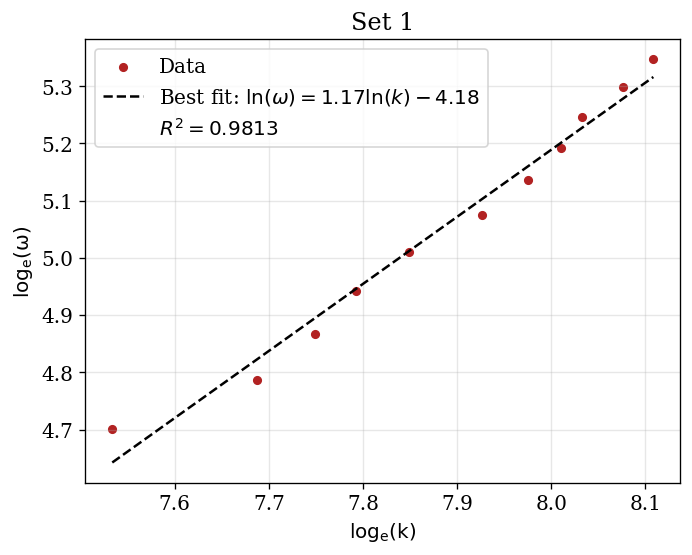

In [249]:
a1,b1= plotlogs(d_array1)
plt.title("Set 1")
tension1 = gettension(b1)
print(tension1)
print(getperc(tension1), " %")

0.006192584391755837
91.45850428723332  %


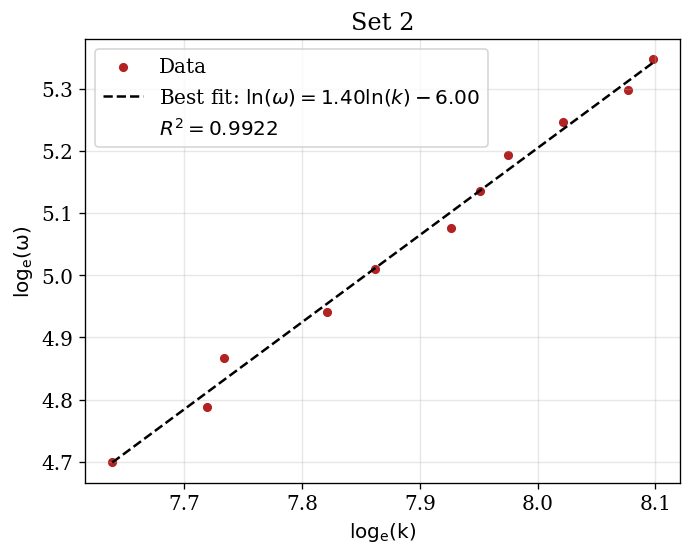

In [250]:
a2,b2 = plotlogs(d_array2)
plt.title("Set 2")
tension2 = gettension(b2)
print(tension2)
print(getperc(tension2), " %")

0.07389709730676249
1.9270307679482628  %


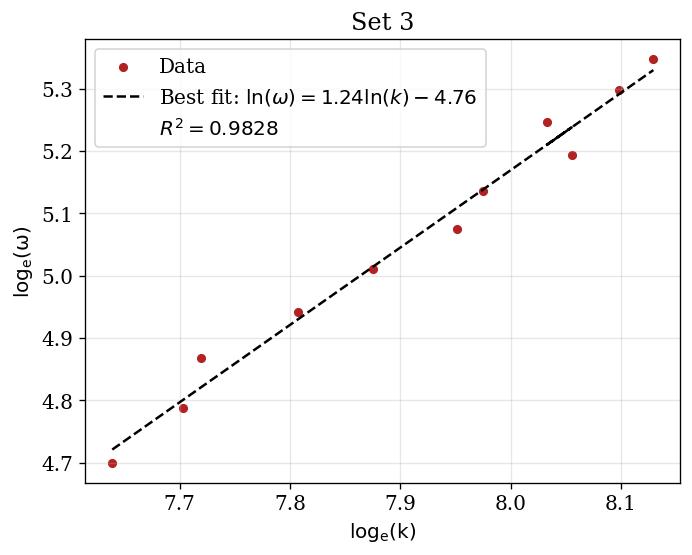

In [251]:
a3,b3 = plotlogs(d_array3)
plt.title("Set 3")
tension3 = gettension(b3)
print(tension3)
print(getperc(tension3), " %")
# plt.savefig("SurfaceT.jpg")

Surface Tension: 0.04384 N/m
Percentage Error: 39.53%


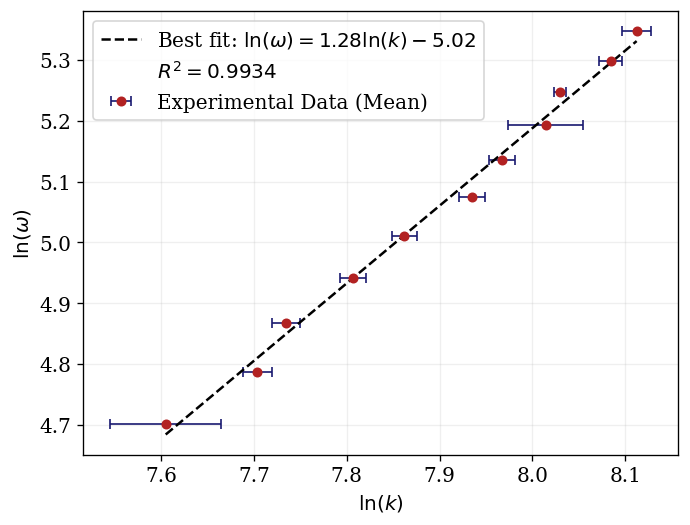

In [252]:
k1 = np.array(getk(d_array1))
k2 = np.array(getk(d_array2))
k3 = np.array(getk(d_array3))

davg = (d_array1 + d_array2 + d_array3) / 3
k_avg = np.array(getk(davg))

k_stack = np.vstack([k1, k2, k3])
k_std = np.std(k_stack, axis=0, ddof=1)

logk = np.log(k_avg)
logw = np.log(w_array)

logk_err = k_std / k_avg

a4, b4 = np.polyfit(logk, logw, deg=1)
y_fit = a4 * logk + b4

plt.errorbar(logk, logw, xerr=logk_err, fmt='o', c='firebrick', 
             ecolor='midnightblue', capsize=3, elinewidth=1, markersize=5, 
             label='Experimental Data (Mean)')

plt.plot(logk, y_fit, ls="--", c='k', 
         label=fr"Best fit: $\ln(\omega) = {a4:.2f}\ln(k) - {abs(b4):.2f}$")

rsqval = rsq(logw, y_fit)

plt.xlabel(r"$\ln(k)$")
plt.ylabel(r"$\ln(\omega)$")
plt.grid(alpha=0.2)

plt.plot([], [], ' ', label=fr"$R^2 = {rsqval:.4f}$")
plt.legend()


tension4 = gettension(b4)
print(f"Surface Tension: {tension4:.5f} N/m")
print(f"Percentage Error: {getperc(tension4):.2f}%")
plt.savefig("avgSurface.jpg")